In [1]:
from spiral import Spiral

sp = Spiral()
project = sp.project("external-805943")

experiments_table = project.table("experiments")
eye_trackers_table = project.table("eye-trackers-v2")
responses_table = project.table("responses-v2")
screens_table = project.table("screens-v2")

In [2]:
# Schema now uses step (int64) as key instead of time (float32)
eye_trackers_table.schema()

Schema({data_key=utf8?, step=i64?, time=f32?, x=f32?, y=f32?, pupil=f32?})

In [3]:
# Schema now uses step (int64) as key instead of time (float32)
responses_table.schema()

Schema({data_key=utf8?, step=i64?, time=f32?, signals=list(f32?)?})

In [9]:
# Schema now uses step (int64) as key, and frame is fixed_size_list<float16>[297360]
# TODO(marko): `frame` should be a list instead of fixed_size_list to allow for variable size frames.
screens_table.schema()

Schema({data_key=utf8?, step=i64?, time=f32?, frame=fixed_size_list(f16?)[297360]?})

In [10]:
# Scan is a list of projections.
# Most commonly used projections are column sections.
# But projections that transform column, like slicing a list column, are also possible.
experiment = sp.scan(
    experiments_table[[
        "*",
        "config",
        # * means select columns but do not recurse into sub-column groups.
        "eye_tracker.*",
    ]],
    # Pack result of responses selection back into "responses" column.
    {
        # Customize selection of responses further to drop some sequences we don't need.
        "responses": experiments_table["responses"].select(exclude=["means", "stds"])
    },
    where=experiments_table["data_key"] == "35_3832003544063_1_V1"
).to_table().to_pylist()[0]

experiment

{'data_key': '35_3832003544063_1_V1',
 'config': {'database': {'host': 'at-database3.stanford.edu',
   'password': '',
   'schema_name': 'enigma_acq',
   'user': ''},
  'export': {'compute_report': True,
   'default_fs': 30000,
   'export_suffix': 'permissive_stability_criteria',
   'output_base_dir': '/mnt/stor02/enigma/modeling_pipeline/export/goliath_malachi_v0_3_0/',
   'overwrite': False,
   'target_sampling_rate': 30,
   'use_functional_criteria': False,
   'use_regularity_criteria': False,
   'use_stability_criteria': True,
   'quality_thresholds': {'good_spikes_fraction': 0.3,
    'loo_slope': 0.1,
    'presence_ratio': 0.8,
    'variance_explained': 0.1}},
  'gaze': {'behavior_mnt_dir': ['/mnt/scratch14/', '/mnt/scratch12/'],
   'blink_acc_threshold': 150000.0,
   'blink_detection': False},
  'processing': {'n_jobs': 10},
  'screen': {'dtype': 'float16',
   'frame_t_max': 0.04,
   'frame_t_min': 0.026,
   'frames_in_split': 50,
   'gray_value': 128.0,
   'max_delta_pauses': 0.

In [14]:
import pyarrow as pa
import numpy as np

# TODO(marko): SP-223 removed the need for this
def constant_array(value, length, pa_type):
    """
    Create a constant array in PyArrow with optimal memory efficiency.

    Parameters:
    -----------
    value : any
        The constant value to repeat
    length : int
        The length of the array
    pa_type : pa.DataType
        The PyArrow data type

    Returns:
    --------
    pa.Array
        A constant array with the specified value repeated
    """
    # Create a scalar with the specified type
    scalar = pa.scalar(value, type=pa_type)

    # Use repeat to create a constant array efficiently
    # This uses run-length encoding internally for maximum efficiency
    return pa.repeat(scalar, length)

In [15]:
# TODO(marko): SP-208 makes this cheap
signals_scan = sp.scan(responses_table.select("signals"))

# Result schema.
signals_scan.schema

Schema({signals=list(f32?)?})

In [48]:
# Scan can repeatedly be used to fetch results with a different key tables.
# TODO(marko): SP-223 makes this nicer
signals = signals_scan.to_table(key_table=pa.table({
    "data_key": constant_array("35_3832003544063_1_V1", 25_000, pa.string()),
    "step": pa.array(range(100_000, 125_000), type=pa.int64()),
}))

signals

pyarrow.Table
signals: list<item: float>
  child 0, item: float
----
signals: [[[0,0,0,0,0,...,0,0,0,0,0],[0,0,0,0,0,...,0,0,0,0,0],...,[0,1,0,0,0,...,0,0,0,1,0],[0,0,0,1,0,...,1,0,0,0,0]],[[0,0,0,0,0,...,1,0,0,0,0],[0,0,1,0,0,...,1,0,0,0,0],...,[0,0,0,0,0,...,0,0,0,0,0],[0,1,0,0,0,...,0,0,0,0,0]]]

In [17]:
eye_tracker_scan = sp.scan(eye_trackers_table.select("x", "y", "pupil"), where=eye_trackers_table["data_key"] == "35_3832003544063_1_V1")

eye_tracker_scan.schema

Schema({x=f32?, y=f32?, pupil=f32?})

In [18]:
# Get all eye tracker data for an experiment (filter applied on scan).
eye_tracker_scan.to_table()

pyarrow.Table
x: float
y: float
pupil: float
----
x: [[189.43404,189.36218,189.4979,189.54979,189.44202,...,-114.86065,-114.760864,-114.768845,-114.53334,-114.8367]]
y: [[-79.00198,-78.95872,-78.802315,-78.97203,-79.24491,...,-35.833954,-35.784035,-35.43129,-35.697514,-35.391357]]
pupil: [[-99497,-99520,-99491,-99535,-99525,...,-99112,-99118,-99081,-99059,-99081]]

In [19]:
# Scan screen frames for a specific experiment
screens_scan = sp.scan(
    screens_table.select("step", "time", "frame"),
    where=screens_table["data_key"] == "35_3832003544063_1_V1"
)

screens_scan.schema

Schema({step=i64?, time=f32?, frame=fixed_size_list(f16?)[297360]?})

In [20]:
# Fetch a range of frames by step
# TODO(marko): SP-223 makes this nicer
frames_table = screens_scan.to_table(key_table=pa.table({
    "data_key": constant_array("35_3832003544063_1_V1", 100, pa.string()),
    "step": pa.array(range(100, 200), type=pa.int64()),
}))

frames_table

pyarrow.Table
step: int64
time: float
frame: fixed_size_list<item: halffloat>[297360]
  child 0, item: halffloat
----
step: [[100,101,102,103,104,...,195,196,197,198,199]]
time: [[120.65949,120.69283,120.72616,120.75947,120.79283,...,123.82621,123.859535,123.89287,123.926186,123.95953]]
frame: [[[0.75439453125,0.67822265625,0.0924072265625,0.73876953125,0.66259765625,...,-1.4072265625,-1.125,-1.44140625,-1.4072265625,-1.125],[0.6015625,0.48876953125,0.0467529296875,0.7236328125,0.615234375,...,-1.390625,-1.0947265625,-1.45703125,-1.390625,-1.0947265625],...,[-0.419921875,-0.474853515625,-0.59228515625,-0.419921875,-0.474853515625,...,-1.4541015625,-1.109375,-1.5029296875,-1.4541015625,-1.109375],[-0.465576171875,-0.49072265625,-0.59228515625,-0.465576171875,-0.49072265625,...,-1.4541015625,-1.109375,-1.5029296875,-1.4541015625,-1.109375]]]

In [41]:
# Convert frames to numpy array with shape (N, H, W, C)
frame_height = experiment["config"]["screen"]["new_h"]
frame_width = experiment["config"]["screen"]["new_w"]

frames_np = np.stack(frames_table["frame"].to_numpy(zero_copy_only=False)).reshape(frames_table.num_rows, frame_height, frame_width, 3)

print(f"Shape: {frames_np.shape}")
print(f"Dtype: {frames_np.dtype}")
print(f"Value range: {frames_np.min():.2f} to {frames_np.max():.2f}")

Shape: (100, 236, 420, 3)
Dtype: float16
Value range: -1.55 to 2.46


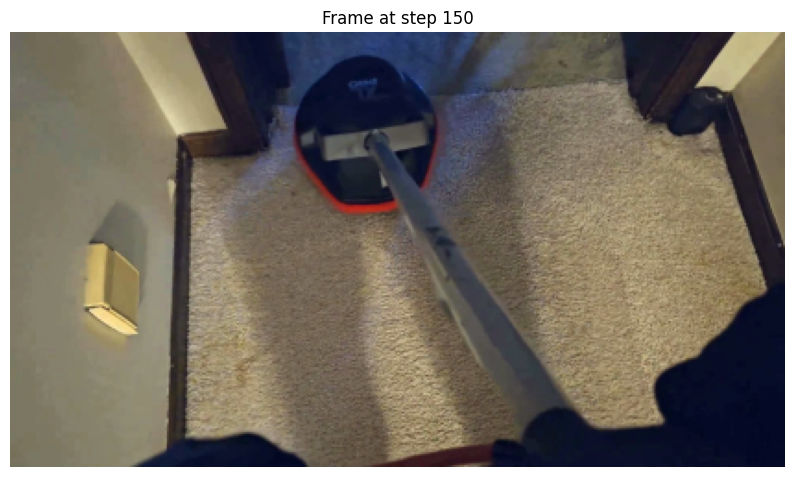

In [42]:
# Visualize a frame
import matplotlib.pyplot as plt

def show_frame(frame, title="Frame"):
    """Display a frame. Normalizes from z-scored values to [0, 1] for display."""
    # Convert to float32 (matplotlib doesn't support float16)
    frame = frame.astype(np.float32)
    frame_norm = (frame - frame.min()) / (frame.max() - frame.min())
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_norm)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_frame(frames_np[50], title="Frame at step 150")

In [45]:
# Convert eye tracker data to numpy array with shape (N, 3)
eye_tracker_table = eye_tracker_scan.to_table()

eye_tracker_np = np.stack([
    eye_tracker_table["x"].to_numpy(),
    eye_tracker_table["y"].to_numpy(),
    eye_tracker_table["pupil"].to_numpy(),
], axis=1)

print(f"Eye tracker shape: {eye_tracker_np.shape}")
print(f"Dtype: {eye_tracker_np.dtype}")

Eye tracker shape: (2169430, 3)
Dtype: float32


In [49]:
# Convert signals to numpy array with shape (N, n_signals)
signals_np = np.stack(signals["signals"].to_numpy(zero_copy_only=False))

print(f"Signals shape: {signals_np.shape}")
print(f"Dtype: {signals_np.dtype}")

Signals shape: (25000, 1225)
Dtype: float32
